# DATA 201 Capstone Project: Citi Bike Summer Usage Analysis  
## Preparing for the 2026 FIFA World Cup

### Motivation
New York City sees its highest Citi Bike usage in the summer because of warm weather and increased tourism. With the 2026 FIFA World Cup approaching, millions of international fans will visit the New York and New Jersey area — especially for the World Cup Final on July 19, 2026 at MetLife Stadium.

With the recent announcement by NJ Transit to charge USD150 for an 18mins train ride from Penn station during matchdays on a trip that previously cost commuters less than $20, This creates a great opportunity for sustainable transportation. By encouraging more people to use Citi Bike instead of cars or crowded subways, we can reduce traffic congestion and lower carbon emissions during this massive event.

That’s why I chose to analyze July 2025 data — it gives a clear baseline of current summer patterns so Citi Bike can better prepare for the expected surge in visitors.

My research question for this capstone project is: How do casual riders (mostly tourists) and annual members differ in usage patterns during peak summer? And what insights can help Lyft (operators of Citi bike) prepare for the 2026 World Cup crowds?




### Data Source

For this project, I used the official Citi Bike System Data for July 2025. The data is publicly available and can be downloaded from this link that was share by Prof: https://s3.amazonaws.com/tripdata/202507-citibike-tripdata.zip.

To be honest, this dataset is quite large — it contains millions of individual bike trips. It includes important columns such as when the ride started and ended, whether the bike was classic or electric, and whether the rider was a casual user or an annual member.

In my notebook, I had to combine multiple CSV files because Citi Bike splits large months into several parts.



**Import Libraries and Load the Data**


In [ ]:
# Import  and load trip data
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
# Download and load the data
url = url = "https://s3.amazonaws.com/tripdata/202507-citibike-tripdata.zip"

In [ ]:
import zipfile
import requests
from io import BytesIO


response = requests.get(url)
with zipfile.ZipFile(BytesIO(response.content)) as z:
    df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
df = pd.concat(df_list, ignore_index=True)

/tmp/ipykernel_5152/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_5152/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_5152/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_5152/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_5152/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=Fal

###**Cleaning the data**
I performed six different data transformations, including:

•	Converting the date columns to proper datetime format, setting that as my index

•	Calculating trip duration in minutes,

•	Extracting the hour of the day and whether it was a weekend,

•	And cleaning out unrealistic trips.

I run a heatmap of the data to check rows and columns which have null data and dropped same.


<Axes: >

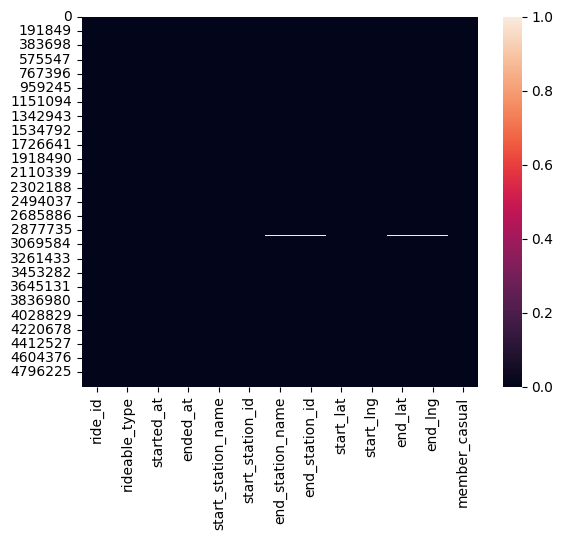

In [ ]:
# Lets look for columns that have null data using heatmap
sns.heatmap(df.isnull())

In [ ]:
# This is the length of our raw data
print(len(df))

4988053


In [ ]:
# We see with the heatmap that the data has some missing data which are within columns that will not be part of my analysis.
# Let's take a loook at it in more details
df.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,2997
start_station_id,2997
end_station_name,19713
end_station_id,20399
start_lat,2997
start_lng,2997


In [ ]:
# This is our dataframe before dropping rows and columns
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4DD2787D61CF3241,electric_bike,2025-07-18 17:25:37.739,2025-07-18 17:47:53.285,49 St & 25 Ave,6804.01,48 St & Broadway,6629.06,40.764496,-73.904632,40.755763,-73.912715,casual
1,773CBF1A04FD71AB,electric_bike,2025-07-19 15:28:29.468,2025-07-19 16:04:17.964,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
2,D68E54237896E734,electric_bike,2025-07-17 23:27:57.316,2025-07-17 23:40:52.640,Leonard St & Church St,5359.11,Liberty St & Broadway,5105.01,40.717571,-74.005549,40.709056,-74.010434,casual
3,925D499017AC875C,electric_bike,2025-07-24 13:37:21.526,2025-07-24 13:44:39.234,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
4,2E66E951D8461F26,electric_bike,2025-07-27 18:58:50.703,2025-07-27 19:21:55.612,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988048,D67680B8F55CD63B,classic_bike,2025-07-02 15:52:13.622,2025-07-02 16:05:43.590,E 4 St & Ave B,5515.08,E 22 St & 2 Ave,5971.09,40.723347,-73.982659,40.737169,-73.981225,casual
4988049,9FCE417C5B5D8D24,electric_bike,2025-07-04 19:12:49.316,2025-07-04 19:37:21.340,E 26 St & 3 Ave,6089.11,Market St & Henry St,5270.09,40.740693,-73.981606,40.713107,-73.994464,casual
4988050,A6546FC3F685D408,electric_bike,2025-07-02 13:17:23.726,2025-07-02 13:46:07.592,Riverside Dr & W 82 St,7388.10,Lafayette St & E 8 St,5788.13,40.787209,-73.981281,40.730207,-73.991026,member
4988051,49B8E6FA2714D82E,classic_bike,2025-07-13 17:30:04.622,2025-07-13 17:48:58.953,Riverside Dr & W 82 St,7388.10,Riverside Dr & W 82 St,7388.10,40.787209,-73.981281,40.787209,-73.981281,member


In [ ]:
# I decided to drop all the rows with missing data
rows_dropped = len(df) - len(df.dropna(axis=0))
print(f"We will drop {rows_dropped} rows")
df = df.dropna(axis=0)

We will drop 22915 rows


In [ ]:
# After dropping all empty rows and columns,
# this is the length of the df
df.shape

(4965138, 14)

In [ ]:
# lets set the index using started_at and ended_at to datetime format.
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [ ]:
# lets create a new column for trip duration in minutes to know how long each rider travels
df['trip_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

In [ ]:
# lets Extract hour of day
df['hour'] = df['started_at'].dt.hour

In [ ]:
# lets categorize the hours of the day into time-of-day to help determine which time of the day does riders prefer mostly.
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_category'] = df['hour'].apply(categorize_time)

# Show the new distribution
print(df['time_category'].value_counts())

time_category
Evening      1494186
Afternoon    1435991
Morning      1338532
Night         696429
Name: count, dtype: int64


<Axes: xlabel='time_category', ylabel='count'>

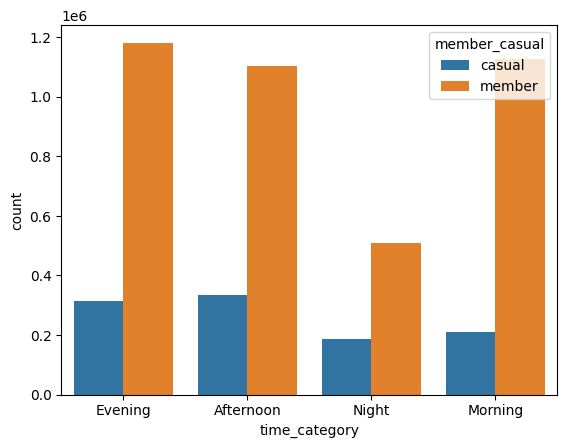

In [ ]:
# Graphical representation of the time of the day by member description type
sns.countplot(data=df, x="time_category", hue="member_casual")

In [ ]:
# Lets make rider type and bike type lowercase
df['member_casual'] = df['member_casual'].str.lower()
df['rideable_type'] = df['rideable_type'].str.lower()

In [ ]:
# Lets remove unrealistic trips and keep only trips between 1 minute and 4 hours
df = df[(df['trip_duration_min'] >= 1) & (df['trip_duration_min'] <= 240)].copy()

###**Data is ready for analysis.** - Lets describe our df, plot our class and graphs, draw linear regression analysis and differential statistics

In [ ]:
# Lets take a look at the average trip duration by rider type
print("Trip Duration by Rider Type:")
print(df.groupby('member_casual')['trip_duration_min'].describe())

Trip Duration by Rider Type:
                   count       mean        std       min       25%        50%  \
member_casual                                                                   
casual         1042459.0  18.621035  18.581198  1.000983  7.856992  13.244533   
member         3919146.0  11.565154  10.027471  1.000167  5.085567   8.679717   

                     75%         max  
member_casual                         
casual         22.755175  239.974667  
member         14.836192  239.739083  


<Axes: xlabel='rideable_type', ylabel='count'>

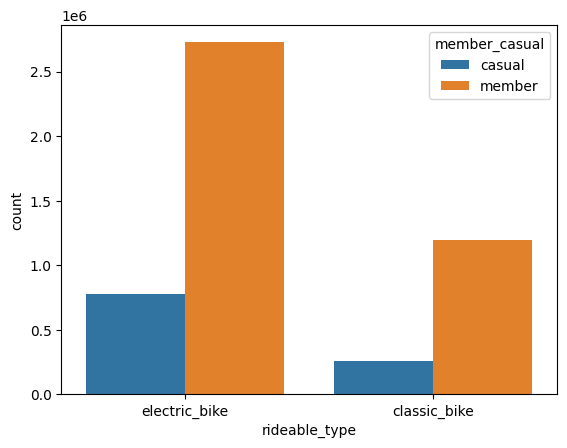

In [ ]:
# A class to manage the World Cup Analysis
sns.countplot(data=df, x="rideable_type", hue="member_casual")

In [ ]:
# Inferential statistics: t-test to see if casual riders take longer trips than members
casual = df[df['member_casual'] == 'casual']['trip_duration_min']
member = df[df['member_casual'] == 'member']['trip_duration_min']

t_stat, p_value = stats.ttest_ind(casual, member, equal_var=False)

In [ ]:
print("\nT-test p-value:", round(p_value, 5))
if p_value < 0.05:
    print("→ Significant difference: Casual riders take longer trips than members.")


T-test p-value: 0.0
→ Significant difference: Casual riders take longer trips than members.


Intercept (Base duration): 11.43 minutes
Coefficient (Change per hour): 0.11
R-squared (Model fit): 0.0023


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


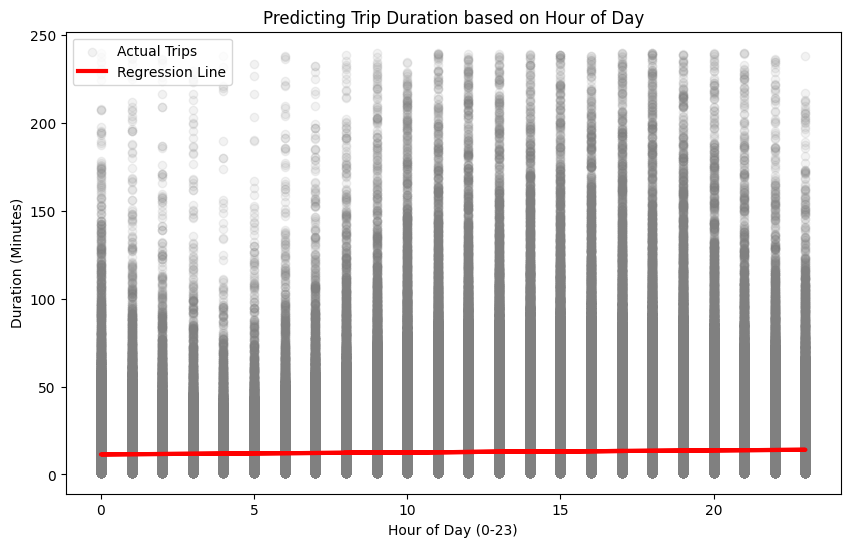

In [ ]:
# Visualize the Regression Line
from sklearn.linear_model import LinearRegression

# Prepare the data
# We reshape the X variable because Scikit-Learn expects a 2D array
X = df[['hour']]
y = df['trip_duration_min']

# 2. Create and train the model
model = LinearRegression()
model.fit(X, y)

# 3. Get the results
intercept = model.intercept_
coefficient = model.coef_[0]
r_squared = model.score(X, y)

print(f"Intercept (Base duration): {intercept:.2f} minutes")
print(f"Coefficient (Change per hour): {coefficient:.2f}")
print(f"R-squared (Model fit): {r_squared:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(df['hour'], df['trip_duration_min'], alpha=0.1, color='gray', label='Actual Trips')
plt.plot(df['hour'], model.predict(X), color='red', linewidth=3, label='Regression Line')
plt.title('Predicting Trip Duration based on Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Duration (Minutes)')
plt.legend()
plt.show()

###**Explanation:** The groupby() shows summary numbers (mean, min, max). The t-test tells us if the difference in trip duration between casual and member riders is real or just by chance. This is our required statistical analysis.


###Data Visualization and Graphs to explain my research question

<Axes: xlabel='hour', ylabel='count'>

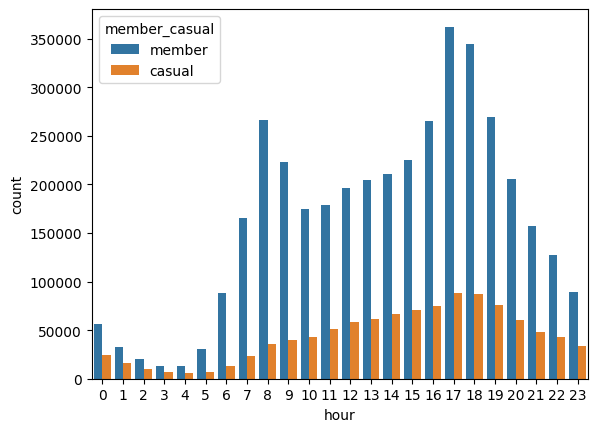

In [ ]:
# Hourly usage by rider type
sns.countplot(data=df, x='hour', hue='member_casual')

<Axes: xlabel='member_casual', ylabel='trip_duration_min'>

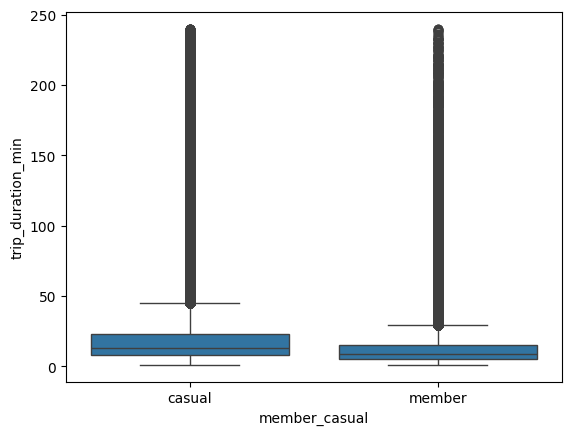

In [ ]:
# Trip duration comparison
sns.boxplot(data=df, x='member_casual', y='trip_duration_min')

###**One Graph That Supports my Conclusion**

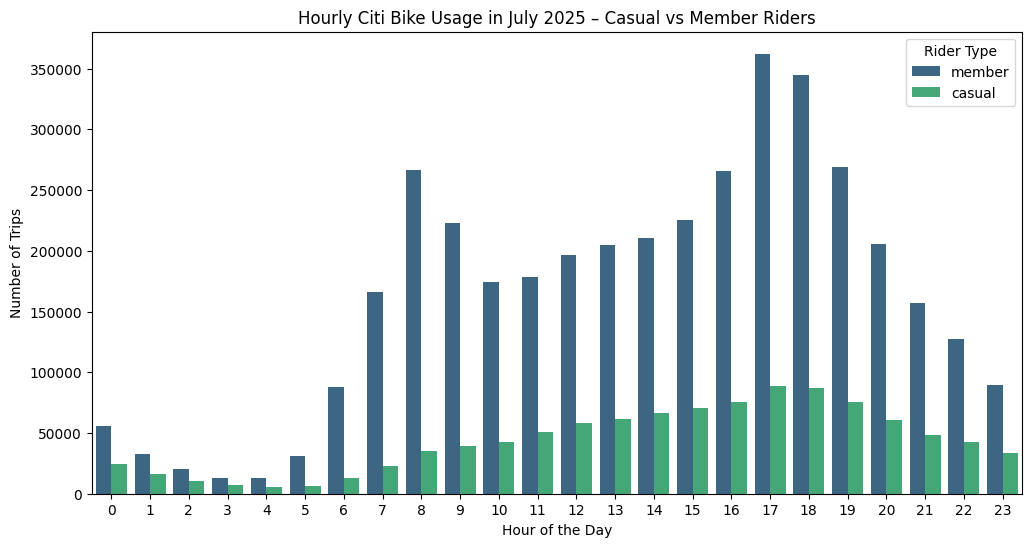

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='hour', hue='member_casual', palette='viridis')
plt.title('Hourly Citi Bike Usage in July 2025 – Casual vs Member Riders')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.legend(title='Rider Type')
plt.show()

###**Conclusions and Recommendations**

To summarize my findings:

Casual riders take longer trips, prefer evening and weekend rides, and often use electric bikes.For the 2026 FIFA World Cup, I recommend that Citi Bike:

•	Create special evening and weekend day-pass promotions targeted at tourists,

•	Increase the number of electric bikes near popular tourist spots and routes leading to MetLife Stadium,

•	Use the July 2025 data as a baseline to plan for much higher demand in July 2026.

Overall, this project shows how data analysis can help improve sustainable transportation during a major global event.


###**References**

Citi Bike System Data: https://s3.amazonaws.com/tripdata/index.html

2026 FIFA World Cup information (NY/NJ host venues)